<a href="https://colab.research.google.com/github/songnee/test/blob/main/2_%E1%84%92%E1%85%AC%E1%84%80%E1%85%B1%E1%84%91%E1%85%A7%E1%86%BC%E1%84%80%E1%85%A1%E1%84%8C%E1%85%B5%E1%84%91%E1%85%AD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. 지도학습 평가

### 가설 함수 (Hypothesis Function)
- 최적선을 찾아내기 위해 시도해보는 다양한 함수들
$$
h_\theta(x) = \theta_0 + \theta_1x_1 + \theta_2x_2 + \dots + \theta_nx_n
$$
### 평가 지표
- 어떤 가설 함수가 데이터셋에 가장 적합할지 판단해주는 기준이 되는 지표들
- MAE, MAPE, MSE, RMSE, MSLE, R2 Score 등

In [ ]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Importing the dataset
dataset = pd.read_csv('./dataset/Salary_Data.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1/3, random_state = 0)

# Training the Simple Linear Regression model on the Training set
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Predicting the Test set results
y_pred = regressor.predict(X_test)

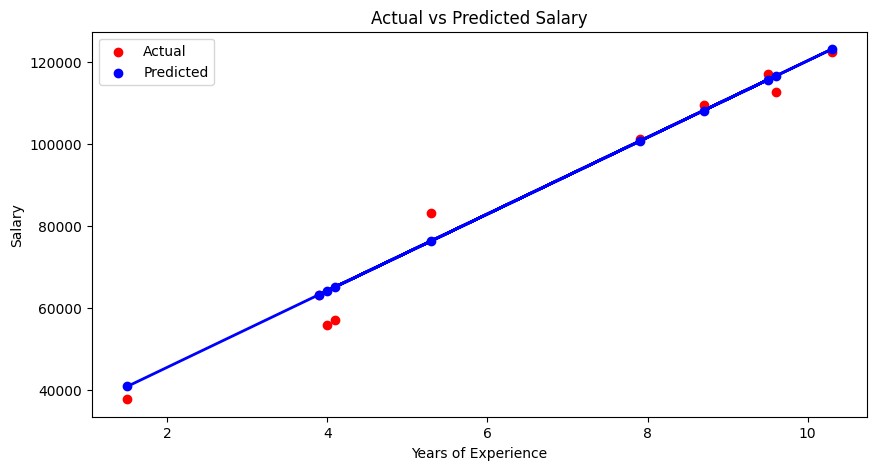

In [ ]:
# 시각화 비교

plt.figure(figsize=(10,5))
plt.scatter(X_test, y_test, color='red', label='Actual')
plt.scatter(X_test, y_pred, color='blue', label='Predicted')
plt.plot(X_test, y_pred, color='blue', linewidth=2)
plt.title('Actual vs Predicted Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

#### 모델 평가지표 적용
- [sklearn metrics DOCS](https://scikit-learn.org/stable/api/sklearn.metrics.html)

#### 1. MAE (Mean Absolute Error)

<img src="https://velog.velcdn.com/images/newnew_daddy/post/dbc9ba6b-52ab-44ab-b208-07b3d97bbca7/image.png" width="70%">

$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y_i}|$$
- 실제값과 예측값의 차이에 대한 절대값의 평균
- 직관적이고 해석하기 쉬운 지표로, 모든 에러를 동일하게 취급

In [ ]:
from sklearn.metrics import mean_absolute_error

print(mean_absolute_error(y_test, y_pred))

3426.426937430709


#### 2. MAPE (Mean Absolute Percentage Error)

<img src="https://velog.velcdn.com/images/newnew_daddy/post/a998f37c-f2d5-47f9-a97e-9c679ba8b3a8/image.png" width="70%">

$$\text{MAPE} = \frac{1}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y_i}}{y_i} \right| \times 100\%$$
- 에러 비율((실제값 - 예측값)/실제값)의 절대값에 대한 평균
- MAE를 퍼센트로 변환한 값

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

print(mean_absolute_percentage_error(y_test, y_pred))

0.05261897682192561


#### 3. MSE (Mean Squared Error)

<img src="https://velog.velcdn.com/images/newnew_daddy/post/e916b8de-5dc4-424d-a419-d1545b6fa787/image.png" width="70%">

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y_i})^2$$
- 에러(실제값 - 예측값) 제곱의 평균
- 차이에 제곱을 취하므로 큰 에러에 대해 더 큰 패널티를 부여하게 됨

In [ ]:
from sklearn.metrics import mean_squared_error

print(mean_squared_error(y_test, y_pred))

21026037.329511303


#### 4. RMSE (Root Mean Squared Error)

$$\text{RMSE} = \sqrt{\text{MSE}}$$
- MSE의 제곱근으로, 에러의 표준편차를 나타냅니다.

In [ ]:
from sklearn.metrics import root_mean_squared_error

print(root_mean_squared_error(y_test, y_pred))

4585.415720467589


#### 5. MSLE (Mean Squared Logarithmic Error)

$$\text{MSLE} = \frac{1}{n} \sum_{i=1}^{n} \left(\log(1 + y_i) - \log(1 + \hat{y_i})\right)^2$$
- 실제값과 예측값의 로그 차이에 대한 제곱 평균
- 로그 변환을 통해 값의 차이를 상대적으로 측정하며, 특히 큰 차이가 발생할 수 있는 상황에서의 성능을 평가할 때 유용
- 로그 함수의 특성상, 예측값이 실제값보다 훨씬 클 때의 페널티는 작으며, 반대로 실제값이 작을 때의 예측 에러에 민감

In [ ]:
from sklearn.metrics import mean_squared_log_error

print(mean_squared_log_error(y_test, y_pred))

#### 6. R2 Score

$$\text{R}^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y_i})^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2} = 1 - \frac{(실제값 - 예측값)^2 합}{(실제값 - 평균)^2 합}$$
- 회귀 모델에서 독립변수가 종속변수를 얼마나 잘 설명해주는지 보여주는 지표로, 1에 가까울수록 좋은 모델
- 실제값의 분산 대비 예측값의 분산을 비교하여 계산됨

In [ ]:
from sklearn.metrics import r2_score

print(r2_score(y_test, y_pred))

0.9749154407708353


### 회귀 평가지표 6종 비교

| 지표 | 핵심 의미 | 장점 | 한계/주의점 | 주로 활용할 때 |
|---|---|---|---|---|
| **MAE** | 오차 절대값의 평균 | 단위가 원래 타깃과 같아 해석이 직관적, 이상치 영향이 비교적 완만 | 큰 오차와 작은 오차를 동일 가중치로 취급 | 실제 오차 크기를 직관적으로 보고 싶을 때, 이상치가 일부 있어도 안정적인 기준이 필요할 때 |
| **MAPE** | 실제값 대비 오차 비율 평균(%) | 서로 다른 스케일 데이터 간 비교 용이, 비즈니스 보고(%)에 적합 | 실제값이 0 또는 0에 가까우면 왜곡/불안정, 작은 실제값에 과민 | "평균 몇 % 틀렸는가"를 설명해야 할 때, 타깃이 모두 양수이고 0이 거의 없을 때 |
| **MSE** | 오차 제곱의 평균 | 큰 오차에 강한 페널티를 줘 모델이 큰 실수를 줄이도록 유도, 미분 가능해 최적화에 유리 | 단위가 제곱 단위라 해석이 직관적이지 않음, 이상치에 매우 민감 | 큰 오차를 특히 피해야 할 때, 학습 손실함수로 사용할 때 |
| **RMSE** | MSE의 제곱근 | 타깃과 같은 단위라 해석이 쉬우면서도 큰 오차 페널티 유지 | 여전히 이상치 민감, MAE보다 큰 오차 영향 큼 | 모델 성능을 실무 단위로 보고하면서 큰 오차도 중요할 때 |
| **MSLE** | 로그 스케일에서 오차 제곱 평균 | 상대적 오차 관점에 유리, 큰 값/작은 값이 섞인 타깃에서 균형적, 과소예측에 비교적 민감 | 음수 타깃 사용 불가(로그 불가), 원단위 해석 어려움 | 타깃 분포가 치우치고 범위가 큰 경우, 비율적 성능이 중요한 경우 |
| **R2 Score** | 평균 대비 모델 설명력(분산 설명 비율) | 0~1 범위(일반적)로 설명력 비교가 쉬움, 베이스라인(평균 예측) 대비 성능 파악 가능 | 절대 오차 크기를 직접 보여주지 않음, 데이터/문제 맥락에 따라 해석 주의(음수 가능) | 모델의 "설명력"을 빠르게 비교할 때, 다른 오차 지표(MAE/RMSE)와 함께 종합 평가할 때 |

- 집값 1억 → 2억 예측 vs 집값 100억 → 200억 예측 > MSLE 또는 MAPE를 활용하여 균형잡힌 평가
- 큰 오차가 치명적인 비즈니스인 경우 > MSE 보다는 MAE로 페널티 많이

## 2. 실제 예제
#### 보스턴 집값 예측
- CRIM: 지역별 범죄 발생률
- ZN: 25,000평방피트를 초과하는 거주 지역의 비율
- NDUS: 비상업 지역 넓이 비율
- CHAS: 찰스강에 대한 더미 변수(강의 경계에 위치한 경우는 1, 아니면 0)
- NOX: 일산화질소 농도
- RM: 거주할 수 있는 방 개수
- AGE: 1940년 이전에 건축된 소유 주택의 비율
- DIS: 5개 주요 고용센터까지의 가중 거리
- RAD: 고속도로 접근 용이도
- TAX: 10,000달러당 재산세율
- PTRATIO: 지역의 교사와 학생 수 비율
- B: 지역의 흑인 거주 비율
- LSTAT: 하위 계층의 비율
- PRICE: 본인 소유의 주택 가격(중앙값) - 종속변수 (위의 건 독립변수)
- target: 실제 집값


In [ ]:
# 데이터 로딩
import pandas as pd
import numpy as np
import seaborn as sns

df = pd.read_csv('dataset/boston.csv')

df.head(), df.shape

(      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
 0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
 1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
 2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
 3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
 4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   
 
    PTRATIO       B  LSTAT  target  
 0     15.3  396.90   4.98    24.0  
 1     17.8  396.90   9.14    21.6  
 2     17.8  392.83   4.03    34.7  
 3     18.7  394.63   2.94    33.4  
 4     18.7  396.90   5.33    36.2  ,
 (506, 14))

In [ ]:
X = df[df.columns[:-1]].values
y = df['target'].values

X.shape, y.shape

((506, 13), (506,))

In [ ]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

X = ss.fit_transform(X)

In [ ]:
# 데이터 분할 (위에서 StandardScaler를 적용한 X 사용)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((354, 13), (152, 13), (354,), (152,))

In [ ]:
# Linear Regression
from sklearn.linear_model import LinearRegression

# 모델 생성
model = LinearRegression(fit_intercept=True)

In [ ]:
# 모델 학습
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
print("Train : ", model.score(X_train, y_train))
print("Test : ", model.score(X_test, y_test))

Train :  0.7647156501433012
Test :  0.6485645742370695


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    root_mean_squared_error,
    mean_squared_log_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
msle = mean_squared_log_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [ ]:
# 결과 출력
print(f"MAE: {mae}")
print(f"MAPE: {mape}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MSLE: {msle}")
print(f"R2 Score: {r2}")

MAE: 3.6913626771162606
MAPE: 0.19699996167173184
MSE: 28.40585481050831
RMSE: 5.329714327288875
MSLE: 0.16790802166811145
R2 Score: 0.6485645742370695
